In [1]:
import sqlite3
import pandas as pd
import numpy as np
from tqdm import tqdm
import json

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
SQLITE_PATH = "/content/drive/MyDrive/CAP5771-abbhinav.sriram/dev_notebooks/dev_ai_articles_full.sqlite"
DEV_ARTICLES_TABLE = "topic labeled articles"
CHUNK_WORDS = 300


In [4]:
conn = sqlite3.connect(SQLITE_PATH)
cursor = conn.cursor()

In [5]:

df = pd.read_sql_query(f'SELECT * FROM "{DEV_ARTICLES_TABLE}"', conn)
non_tech_df = df.copy()

# Vader sentiment

In [6]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


sia = SentimentIntensityAnalyzer()


In [7]:
def vader_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return "neutral"
    # Chunk and average
    words = text.split()
    chunks = [" ".join(words[i:i+CHUNK_WORDS]) for i in range(0, len(words), CHUNK_WORDS)]
    scores = [sia.polarity_scores(chunk)["compound"] for chunk in chunks]
    score = np.mean(scores)
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

In [8]:
non_tech_df["vader_sentiment"] = non_tech_df["combined_text"].apply(vader_sentiment)



VADER sentiment distribution:
vader_sentiment
positive    4294
negative    1085
neutral       19
Name: count, dtype: int64


,vader_sentiment,count,percent
0,positive,4294,79.55
1,negative,1085,20.10
2,neutral,19,0.35


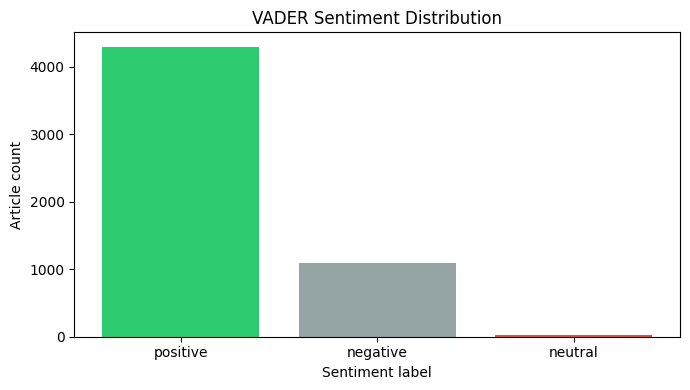

In [9]:
import matplotlib.pyplot as plt
 
print("VADER sentiment distribution:")
print(non_tech_df["vader_sentiment"].value_counts())
 
vader_dist = (
    non_tech_df["vader_sentiment"]
    .value_counts(dropna=False)
    .rename_axis("vader_sentiment")
    .reset_index(name="count")
)
vader_dist["percent"] = (vader_dist["count"] / vader_dist["count"].sum() * 100).round(2)
display(vader_dist)
 
plt.figure(figsize=(7, 4))
plt.bar(vader_dist["vader_sentiment"], vader_dist["count"], color=["#2ecc71", "#95a5a6", "#e74c3c"])
plt.title("VADER Sentiment Distribution")
plt.xlabel("Sentiment label")
plt.ylabel("Article count")
plt.tight_layout()
plt.show()
 

# TextBlob

In [10]:
from textblob import TextBlob
 
def textblob_sentiment(text: str):
    if not isinstance(text, str) or not text.strip():
        return 0.0, 0.0, "neutral"
 
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity        # range: [-1, 1]
    subjectivity = blob.sentiment.subjectivity  # range: [0, 1]
 
    if polarity > 0.05:
        label = "positive"
    elif polarity < -0.05:
        label = "negative"
    else:
        label = "neutral"
 
    return polarity, subjectivity, label
 
non_tech_df[["tb_polarity", "tb_subjectivity", "tb_sentiment"]] = non_tech_df["combined_text"].apply(
    lambda x: pd.Series(textblob_sentiment(x))
)

In [11]:
non_tech_df

,id,title,body_text,combined_text,cluster,primary_label,primary_score,secondary_label,secondary_score,dominant_topic,dominant_topic_prob,vader_sentiment,tb_polarity,tb_subjectivity,tb_sentiment
0,585948,Diamond Hands and the Mechanics of a Short Squ...,title: Diamond Hands and the Mechanics of a Sh...,Diamond Hands and the Mechanics of a Short Squ...,8,UNSURE,0.000000,,0.0,0,0.620216,positive,-0.007114,0.449539,neutral
1,604165,12 Important Software Testing Trends for 2021 ...,Software testing is making many moves. From AI...,12 Important Software Testing Trends for 2021 ...,3,UNSURE,0.000000,,0.0,0,0.800833,positive,0.131818,0.506764,positive
2,628993,"Another 8th of March, yet we are not still there!",Where are we about equality in tech in 2021? A...,"Another 8th of March, yet we are not still the...",3,UNSURE,0.000000,,0.0,0,0.769863,negative,0.042257,0.527893,neutral
3,645109,Top Automation Testing Trends To Look Out In 2021,"Back in the old days, software testing was jus...",Top Automation Testing Trends To Look Out In 2...,3,UNSURE,0.000000,,0.0,0,0.745716,positive,0.159180,0.347962,positive
4,971871,How Cryptocurrency Works Explained Visually,"In 2008, when Lehman Brothers Holdings Inc. fi...",How Cryptocurrency Works Explained Visually In...,8,UNSURE,0.000000,,0.0,3,0.516454,positive,0.047751,0.350094,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5393,69ae116a86766ac3a663b05f,The Copper Ceiling: AI's High-Voltage Collisio...,"When we interact with artificial intelligence,...",The Copper Ceiling: AI's High-Voltage Collisio...,3,TECHNICAL,0.291620,,0.0,4,0.604514,positive,-0.005018,0.483132,neutral
5394,699d48cad00f02a90785119e,Physical AI: Why the Grid’s Operating System S...,As someone working in Developer Relations in t...,Physical AI: Why the Grid’s Operating System S...,3,TECHNICAL,0.263547,,0.0,0,0.565836,positive,0.089474,0.269173,positive
5395,69a889213b896f7ad6749182,I Thought AI Made Me Faster. My Metrics Disagr...,"Friday, 4:47 PM. A PR lands in the repo with a...",I Thought AI Made Me Faster. My Metrics Disagr...,3,TECHNICAL,0.331377,,0.0,0,0.988272,positive,0.148611,0.572222,positive
5396,69a8580ae55311e40f0fd641,You don't know your AI stack.,AI tooling has no supply chain. No audit trail...,You don't know your AI stack. AI tooling has n...,3,TECHNICAL,0.603208,,0.0,0,0.881674,positive,0.105644,0.398469,positive


TextBlob sentiment distribution:
tb_sentiment
positive    3682
neutral     1528
negative     188
Name: count, dtype: int64


,tb_sentiment,count,percent
0,positive,3682,68.21
1,neutral,1528,28.31
2,negative,188,3.48


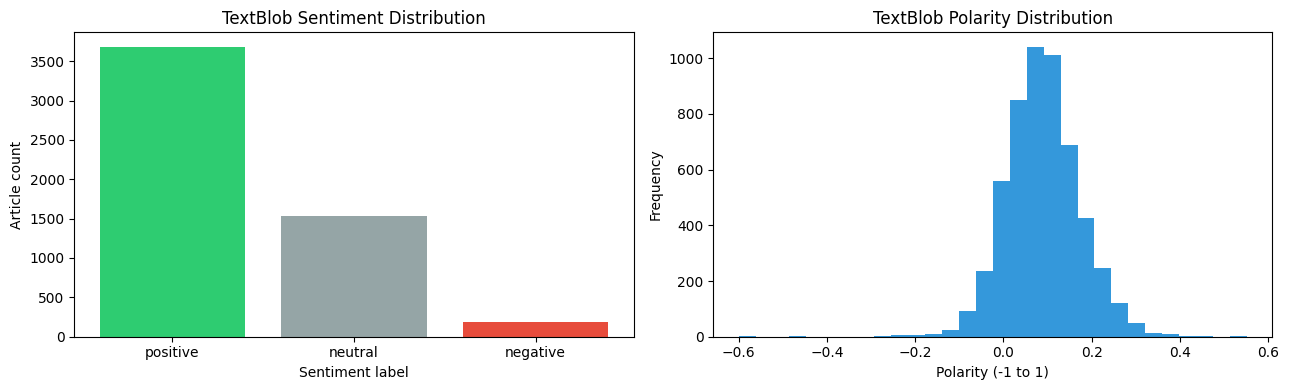

In [12]:
print("TextBlob sentiment distribution:")
print(non_tech_df["tb_sentiment"].value_counts())
 
textblob_dist = (
    non_tech_df["tb_sentiment"]
    .value_counts(dropna=False)
    .rename_axis("tb_sentiment")
    .reset_index(name="count")
)
textblob_dist["percent"] = (textblob_dist["count"] / textblob_dist["count"].sum() * 100).round(2)
display(textblob_dist)
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
 
ax1.bar(textblob_dist["tb_sentiment"], textblob_dist["count"], color=["#2ecc71", "#95a5a6", "#e74c3c"])
ax1.set_title("TextBlob Sentiment Distribution")
ax1.set_xlabel("Sentiment label")
ax1.set_ylabel("Article count")
 
ax2.hist(non_tech_df["tb_polarity"].dropna(), bins=30, color="#3498db")
ax2.set_title("TextBlob Polarity Distribution")
ax2.set_xlabel("Polarity (-1 to 1)")
ax2.set_ylabel("Frequency")
 
plt.tight_layout()
plt.show()

# RoBERTa

In [13]:
from transformers import pipeline, AutoTokenizer, AutoConfig
 
MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
config = AutoConfig.from_pretrained(MODEL)
 
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=MODEL,
    tokenizer=tokenizer,
    truncation=True,
    max_length=512,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
def roberta_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return None, None
 
    words = text.split()
    chunks = [" ".join(words[i:i+CHUNK_WORDS]) for i in range(0, len(words), CHUNK_WORDS)]
 
    scores = {"positive": 0.0, "neutral": 0.0, "negative": 0.0}
    for chunk in chunks:
        result = sentiment_pipeline(chunk)[0]
        label = result["label"].lower()
        scores[label] += result["score"]
 
    # Average across chunks
    total = sum(scores.values())
    for k in scores:
        scores[k] /= total
 
    top_label = max(scores, key=scores.get)
    return top_label, scores
 
non_tech_df[["roberta_label", "roberta_scores"]] = non_tech_df["combined_text"].apply(
    lambda x: pd.Series(roberta_sentiment(x))
)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


RoBERTa sentiment distribution:
roberta_label
neutral     3898
positive    1073
negative     427
Name: count, dtype: int64


,roberta_label,count,percent
0,neutral,3898,72.21
1,positive,1073,19.88
2,negative,427,7.91


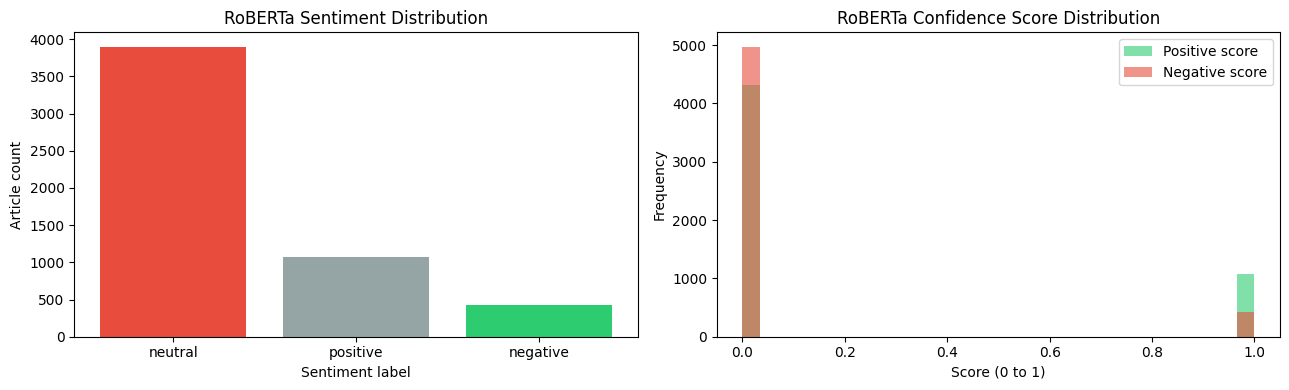

In [15]:
print("RoBERTa sentiment distribution:")
print(non_tech_df["roberta_label"].value_counts())
 
roberta_dist = (
    non_tech_df["roberta_label"]
    .value_counts(dropna=False)
    .rename_axis("roberta_label")
    .reset_index(name="count")
)
roberta_dist["percent"] = (roberta_dist["count"] / roberta_dist["count"].sum() * 100).round(2)
display(roberta_dist)
 
# Extract per-label confidence scores for histogram
non_tech_df["roberta_pos_score"] = non_tech_df["roberta_scores"].apply(
    lambda x: x["positive"] if isinstance(x, dict) else None
)
non_tech_df["roberta_neg_score"] = non_tech_df["roberta_scores"].apply(
    lambda x: x["negative"] if isinstance(x, dict) else None
)
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
 
ax1.bar(roberta_dist["roberta_label"], roberta_dist["count"], color=["#e74c3c", "#95a5a6", "#2ecc71"])
ax1.set_title("RoBERTa Sentiment Distribution")
ax1.set_xlabel("Sentiment label")
ax1.set_ylabel("Article count")
 
ax2.hist(non_tech_df["roberta_pos_score"].dropna(), bins=30, alpha=0.6, label="Positive score", color="#2ecc71")
ax2.hist(non_tech_df["roberta_neg_score"].dropna(), bins=30, alpha=0.6, label="Negative score", color="#e74c3c")
ax2.set_title("RoBERTa Confidence Score Distribution")
ax2.set_xlabel("Score (0 to 1)")
ax2.set_ylabel("Frequency")
ax2.legend()
 
plt.tight_layout()
plt.show()

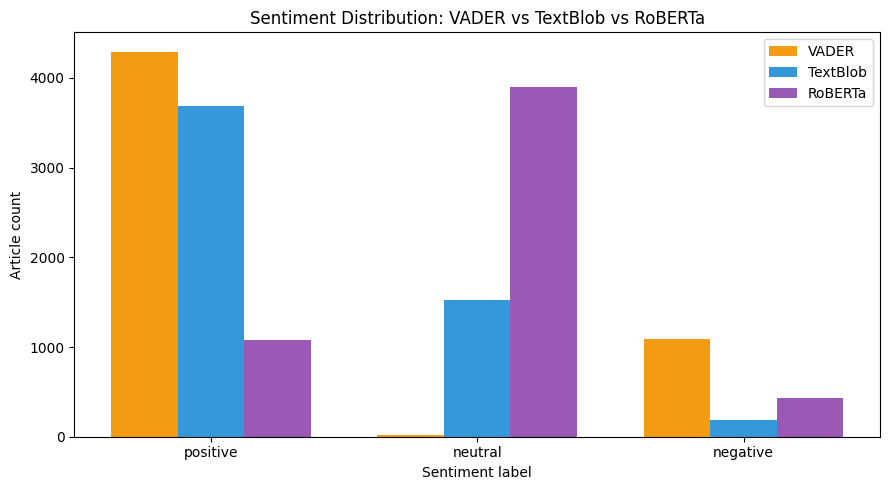

RoBERTa vs VADER agreement:    24.2%
RoBERTa vs TextBlob agreement: 38.6%


In [16]:
labels = ["positive", "neutral", "negative"]
vader_counts   = [non_tech_df["vader_sentiment"].value_counts().get(l, 0) for l in labels]
tb_counts      = [non_tech_df["tb_sentiment"].value_counts().get(l, 0) for l in labels]
roberta_counts = [non_tech_df["roberta_label"].value_counts().get(l, 0) for l in labels]
 
x = np.arange(len(labels))
width = 0.25
 
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, vader_counts,   width, label="VADER",    color="#f39c12")
ax.bar(x,         tb_counts,      width, label="TextBlob", color="#3498db")
ax.bar(x + width, roberta_counts, width, label="RoBERTa",  color="#9b59b6")
 
ax.set_title("Sentiment Distribution: VADER vs TextBlob vs RoBERTa")
ax.set_xlabel("Sentiment label")
ax.set_ylabel("Article count")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()
 
# Agreement rate between RoBERTa and VADER
agreement_vader   = (non_tech_df["roberta_label"] == non_tech_df["vader_sentiment"]).mean()
agreement_tb      = (non_tech_df["roberta_label"] == non_tech_df["tb_sentiment"]).mean()
print(f"RoBERTa vs VADER agreement:    {agreement_vader:.1%}")
print(f"RoBERTa vs TextBlob agreement: {agreement_tb:.1%}")

In [17]:
# Serialize dict column to JSON string before writing to SQLite
non_tech_df["roberta_scores"] = non_tech_df["roberta_scores"].apply(
    lambda x: json.dumps(x) if isinstance(x, dict) else None
)

conn = sqlite3.connect("/content/drive/MyDrive/CAP5771-abbhinav.sriram/dev_notebooks/dev_ai_articles_full.sqlite")
non_tech_df.to_sql("sentiment_articles", conn, if_exists="replace", index=False)
conn.close()

In [19]:

conn = sqlite3.connect("/content/drive/MyDrive/CAP5771-abbhinav.sriram/dev_notebooks/dev_ai_articles_full.sqlite")
cursor = conn.cursor()


df = pd.read_sql_query('SELECT * FROM sentiment_articles', conn)

df

,id,title,body_text,combined_text,cluster,primary_label,primary_score,secondary_label,secondary_score,dominant_topic,dominant_topic_prob,vader_sentiment,tb_polarity,tb_subjectivity,tb_sentiment,roberta_label,roberta_scores,roberta_pos_score,roberta_neg_score
0,585948,Diamond Hands and the Mechanics of a Short Squ...,title: Diamond Hands and the Mechanics of a Sh...,Diamond Hands and the Mechanics of a Short Squ...,8,UNSURE,0.000000,,0.0,0,0.620216,positive,-0.007114,0.449539,neutral,neutral,"{""positive"": 0.0, ""neutral"": 1.0, ""negative"": ...",0.0,0.0
1,604165,12 Important Software Testing Trends for 2021 ...,Software testing is making many moves. From AI...,12 Important Software Testing Trends for 2021 ...,3,UNSURE,0.000000,,0.0,0,0.800833,positive,0.131818,0.506764,positive,positive,"{""positive"": 1.0, ""neutral"": 0.0, ""negative"": ...",1.0,0.0
2,628993,"Another 8th of March, yet we are not still there!",Where are we about equality in tech in 2021? A...,"Another 8th of March, yet we are not still the...",3,UNSURE,0.000000,,0.0,0,0.769863,negative,0.042257,0.527893,neutral,negative,"{""positive"": 0.0, ""neutral"": 0.0, ""negative"": ...",0.0,1.0
3,645109,Top Automation Testing Trends To Look Out In 2021,"Back in the old days, software testing was jus...",Top Automation Testing Trends To Look Out In 2...,3,UNSURE,0.000000,,0.0,0,0.745716,positive,0.159180,0.347962,positive,neutral,"{""positive"": 0.0, ""neutral"": 1.0, ""negative"": ...",0.0,0.0
4,971871,How Cryptocurrency Works Explained Visually,"In 2008, when Lehman Brothers Holdings Inc. fi...",How Cryptocurrency Works Explained Visually In...,8,UNSURE,0.000000,,0.0,3,0.516454,positive,0.047751,0.350094,neutral,neutral,"{""positive"": 0.0, ""neutral"": 1.0, ""negative"": ...",0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5393,69ae116a86766ac3a663b05f,The Copper Ceiling: AI's High-Voltage Collisio...,"When we interact with artificial intelligence,...",The Copper Ceiling: AI's High-Voltage Collisio...,3,TECHNICAL,0.291620,,0.0,4,0.604514,positive,-0.005018,0.483132,neutral,neutral,"{""positive"": 0.0, ""neutral"": 1.0, ""negative"": ...",0.0,0.0
5394,699d48cad00f02a90785119e,Physical AI: Why the Grid’s Operating System S...,As someone working in Developer Relations in t...,Physical AI: Why the Grid’s Operating System S...,3,TECHNICAL,0.263547,,0.0,0,0.565836,positive,0.089474,0.269173,positive,neutral,"{""positive"": 0.0, ""neutral"": 1.0, ""negative"": ...",0.0,0.0
5395,69a889213b896f7ad6749182,I Thought AI Made Me Faster. My Metrics Disagr...,"Friday, 4:47 PM. A PR lands in the repo with a...",I Thought AI Made Me Faster. My Metrics Disagr...,3,TECHNICAL,0.331377,,0.0,0,0.988272,positive,0.148611,0.572222,positive,neutral,"{""positive"": 0.0, ""neutral"": 1.0, ""negative"": ...",0.0,0.0
5396,69a8580ae55311e40f0fd641,You don't know your AI stack.,AI tooling has no supply chain. No audit trail...,You don't know your AI stack. AI tooling has n...,3,TECHNICAL,0.603208,,0.0,0,0.881674,positive,0.105644,0.398469,positive,neutral,"{""positive"": 0.0, ""neutral"": 1.0, ""negative"": ...",0.0,0.0
